<a href="https://colab.research.google.com/github/drtommyhudson77-ai/gdp-dashboard/blob/main/KNN_GapFinder_Datasetipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries and the dataset gap minder as well as K Nearest Neighbours Classifier
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = px.data.gapminder(year=1997)

df.head(50)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
9,Afghanistan,Asia,1997,41.763,22227415,635.341351,AFG,4
21,Albania,Europe,1997,72.950,3428038,3193.054604,ALB,8
33,Algeria,Africa,1997,69.152,29072015,4797.295051,DZA,12
45,Angola,Africa,1997,40.963,9875024,2277.140884,AGO,24
57,Argentina,Americas,1997,73.275,36203463,10967.281950,ARG,32
69,Australia,Oceania,1997,78.830,18565243,26997.936570,AUS,36
81,Austria,Europe,1997,77.510,8069876,29095.920660,AUT,40
93,Bahrain,Asia,1997,73.925,598561,20292.016790,BHR,48
105,Bangladesh,Asia,1997,59.412,123315288,972.770035,BGD,50
117,Belgium,Europe,1997,77.530,10199787,27561.196630,BEL,56


In [ ]:
# KNN is typically used for classification, so we must define a categorical target.
# Predict continent based on GDP per capita and life expectancy.

X = df[['lifeExp', 'gdpPercap']]
y = df['continent']


In [ ]:
#split the data into training and test sets & scale the data


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





In [ ]:
# Create the KNN model with K=5 and a distance measure of Euclidean


knn = KNeighborsClassifier(
    n_neighbors=6,    # K value
    metric='euclidean')


In [ ]:
# Train the model and make predictions
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

In [ ]:
#evalute the model with an accuracy score and confusion matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
confusion_matrix(y_test, y_pred)




Accuracy: 0.6551724137931034


array([[8, 2, 1, 0],
       [1, 1, 0, 2],
       [1, 0, 4, 2],
       [0, 1, 0, 6]])

Text(0.5, 1.0, 'Confusion Matrix – KNN Classifier')

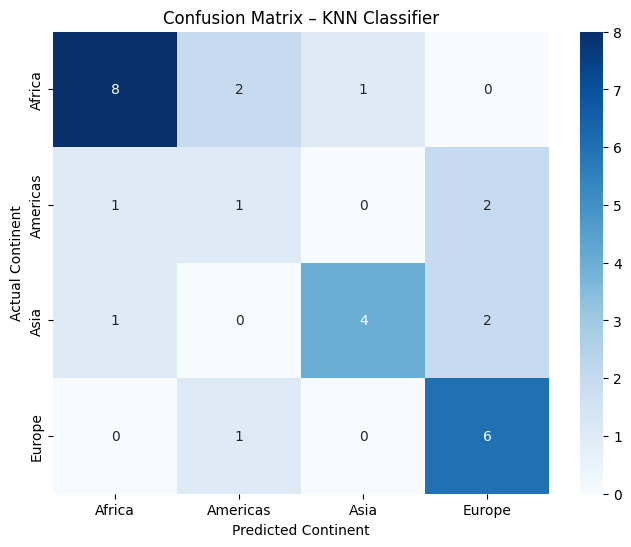

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,          # show numbers in cells
    fmt='d',             # integer format
    cmap='Blues',
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel('Predicted Continent')
plt.ylabel('Actual Continent')
plt.title('Confusion Matrix – KNN Classifier')


In [ ]:

# Precision: The proportion of correct positive predictions among all positive predictions made by the model.
# Recall: The proportion of actual positive cases that were correctly identified by the model.
# F1‑score: A harmonic mean of precision and recall that provides a balanced measure of model performance.

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      Africa       0.80      0.73      0.76        11
    Americas       0.25      0.25      0.25         4
        Asia       0.80      0.57      0.67         7
      Europe       0.60      0.86      0.71         7

    accuracy                           0.66        29
   macro avg       0.61      0.60      0.60        29
weighted avg       0.68      0.66      0.65        29



In [ ]:
# choosing the best K

accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, preds))

print(accuracies)


[0.5862068965517241, 0.4827586206896552, 0.5172413793103449, 0.6206896551724138, 0.5517241379310345, 0.6551724137931034, 0.5172413793103449, 0.5862068965517241, 0.5172413793103449, 0.5862068965517241, 0.5517241379310345, 0.5862068965517241, 0.5862068965517241, 0.5862068965517241, 0.5172413793103449, 0.5172413793103449, 0.5517241379310345, 0.5862068965517241, 0.5862068965517241, 0.5862068965517241]


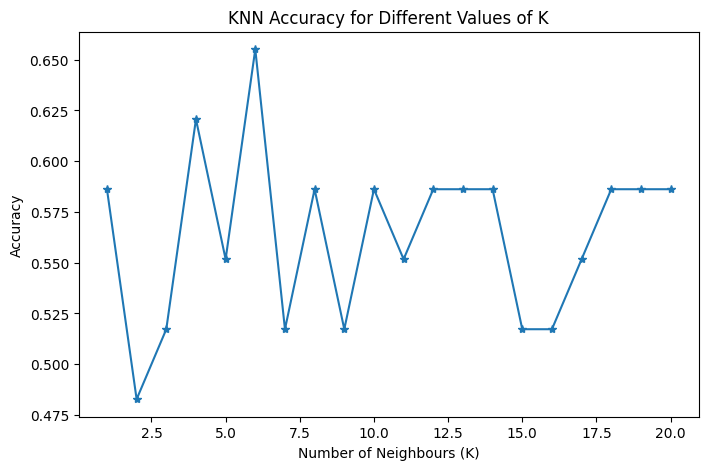

In [ ]:
# create a visual for the best k
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='*')
plt.xlabel('Number of Neighbours (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different Values of K')
plt.show()


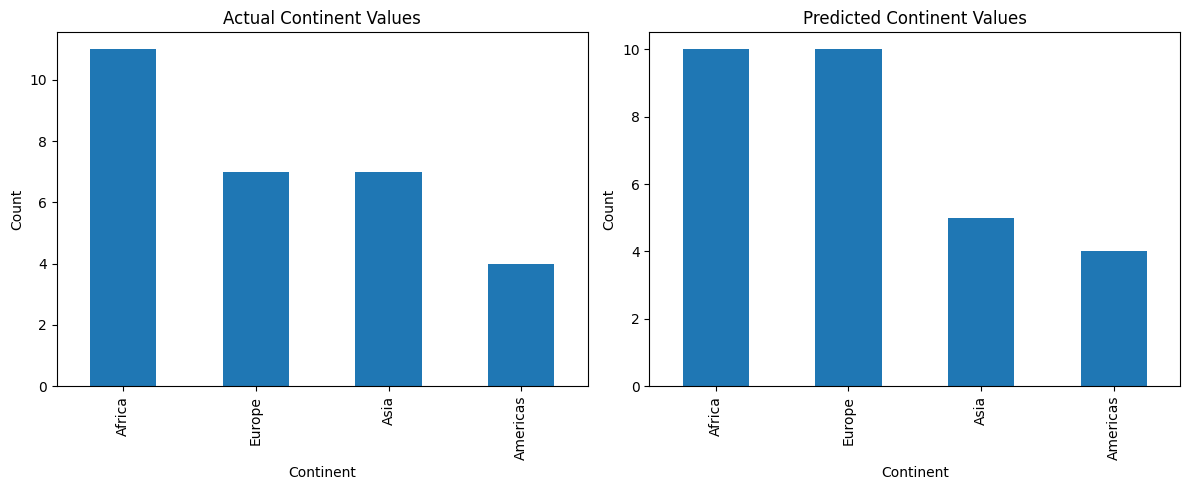

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual values
pd.Series(y_test).value_counts().plot(
    kind='bar',
    ax=axes[0],
    title='Actual Continent Values'
)
axes[0].set_xlabel('Continent')
axes[0].set_ylabel('Count')

# Predicted values
pd.Series(y_pred).value_counts().plot(
    kind='bar',
    ax=axes[1],
    title='Predicted Continent Values'
)
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


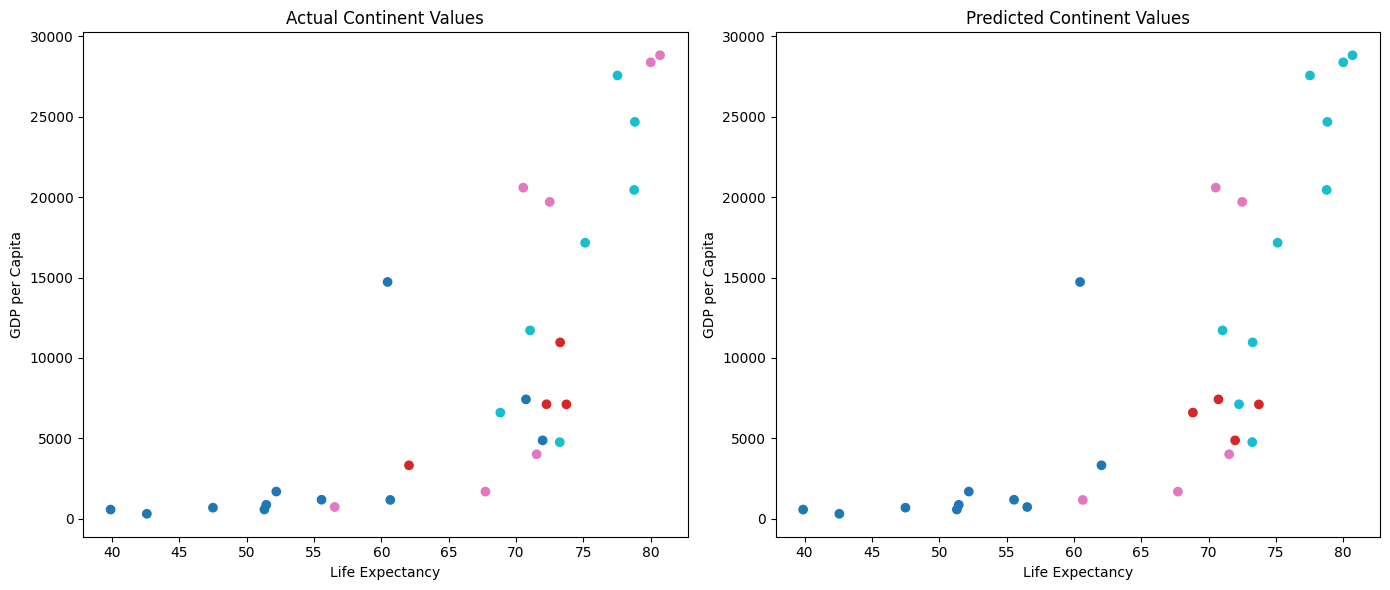

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual values
scatter1 = axes[0].scatter(
    X_test['lifeExp'],
    X_test['gdpPercap'],
    c=pd.Categorical(y_test).codes,
    cmap='tab10'

)
axes[0].set_title('Actual Continent Values')
axes[0].set_xlabel('Life Expectancy')
axes[0].set_ylabel('GDP per Capita')

# Predicted values
scatter2 = axes[1].scatter(
    X_test['lifeExp'],
    X_test['gdpPercap'],
    c=pd.Categorical(y_pred).codes,
    cmap='tab10'
)
axes[1].set_title('Predicted Continent Values')
axes[1].set_xlabel('Life Expectancy')
axes[1].set_ylabel('GDP per Capita')

plt.tight_layout()

plt.show()

In [ ]:

plot_df = X_test.copy()
plot_df['Actual Continent'] = y_test.values
plot_df['country'] = df.loc[X_test.index, 'country']
plot_df['Predicted Continent'] = y_pred


# Convert to long format for side-by-side plots
plot_long = plot_df.melt(
    id_vars=['lifeExp', 'gdpPercap', 'country'],
    value_vars=['Actual Continent', 'Predicted Continent'],
    var_name='Type',
    value_name='Continent'
)


# -----------------------------
# Plot with Plotly Express
# -----------------------------
fig = px.scatter(
    plot_long,
    x='lifeExp',
    y='gdpPercap',
    color='Continent',
    facet_col='Type',

    hover_name='country',   # ✅ country appears in bold
    hover_data={
        'lifeExp': True,
        'gdpPercap': True,
        'Continent': True,
        'Type': False        # hide facet label in tooltip
    },

    facet_col_spacing=0.08,
    title='Actual vs Predicted Continent Values',
    labels={
        'lifeExp': 'Life Expectancy',
        'gdpPercap': 'GDP per Capita'
    }
)

fig.show()


In [ ]:
results_df = pd.DataFrame({
    'Country': df.loc[X_test.index, 'country'],
    'Actual Continent': y_test.values,
    'Predicted Continent': y_pred
})

results_df['Correct Prediction'] = (
    results_df['Actual Continent'] == results_df['Predicted Continent']
)

results_df

,Country,Actual Continent,Predicted Continent,Correct Prediction
1581,Turkey,Europe,Americas,False
237,Cameroon,Africa,Africa,True
981,Mauritius,Africa,Americas,False
1161,Oman,Asia,Asia,True
681,Hungary,Europe,Europe,True
153,Bosnia and Herzegovina,Europe,Europe,True
1185,Panama,Americas,Americas,True
789,Jamaica,Americas,Europe,False
801,Japan,Asia,Europe,False
225,Cambodia,Asia,Africa,False


In [ ]:


import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(results_df.columns),
        fill_color='paleturquoise',
        align='left'
    ),
    cells=dict(
        values=[results_df[col] for col in results_df.columns],
        fill_color='lavender',
        align='left'
    )
)])

fig.show()



NameError: name 'actual_colors' is not defined

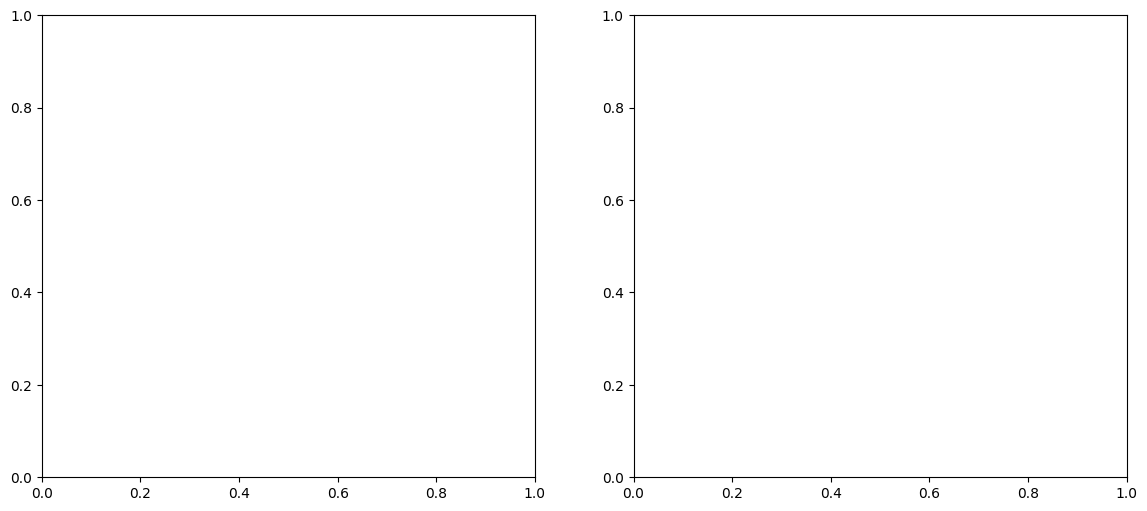

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))





# Actual values
sc_actual = axes[0].scatter(
    X_test['lifeExp'],
    X_test['gdpPercap'],
    c=actual_colors,
    cmap='tab10'
)
axes[0].set_title('Actual Continent Values')
axes[0].set_xlabel('Life Expectancy')
axes[0].set_ylabel('GDP per Capita')

# Create legend FROM the scatter colours
legend1 = axes[0].legend(
    *sc_actual.legend_elements(),
    title="Continent"
)
axes[0].add_artist(legend1)

# Predicted values
sc_pred = axes[1].scatter(
    X_test['lifeExp'],
    X_test['gdpPercap'],
    c=predicted_colors,
    cmap='tab10'
)
axes[1].set_title('Predicted Continent Values')
axes[1].set_xlabel('Life Expectancy')
axes[1].set_ylabel('GDP per Capita')

axes[1].legend(
    *sc_pred.legend_elements(),
    title="Continent"
)



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
# Features: [hours_studied, attended_class]
X = [
    [2, 0],
    [4, 0],
    [6, 1],
    [8, 1],
    [5, 1]
]

# Labels: 0 = Fail, 1 = Pass
y = [0, 0, 1, 1, 1]

clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [ ]:
prediction = clf.predict([[4, 1]])
print(prediction)  # Output:

[0]


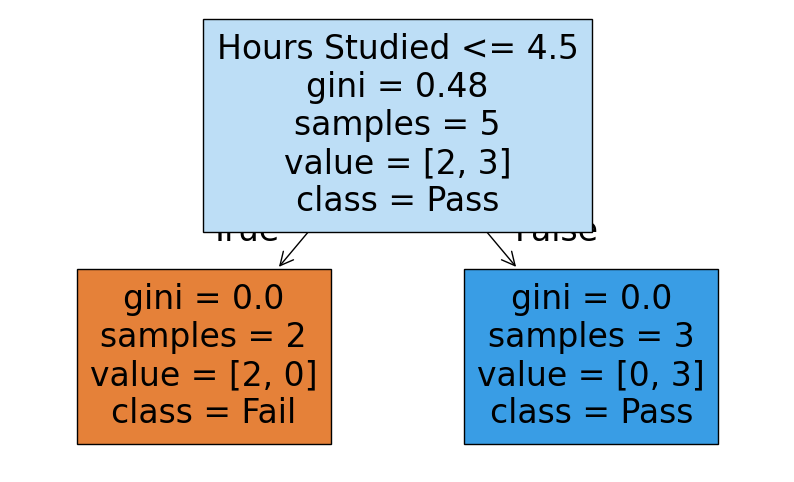

In [ ]:
plt.figure(figsize=(10, 6))
tree.plot_tree(
    clf,
    feature_names=["Hours Studied", "Attended Class"],
    class_names=["Fail", "Pass"],
    filled=True
)
plt.show()

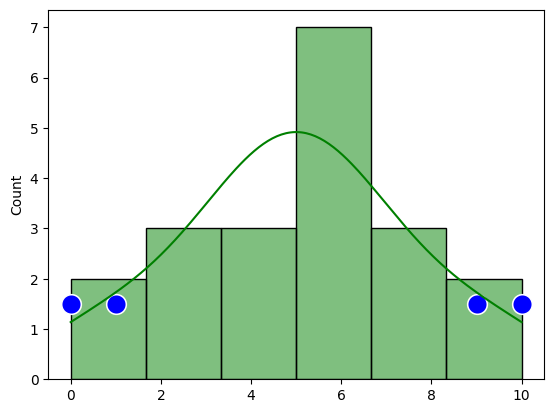

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data = [ 0, 1, 2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7, 8, 9, 10 ]

sns.histplot(data, kde=True, color='green')

import numpy as np

mean = np.mean(data)
std = np.std(data)

outliers = [x for x in data if abs((x - mean)/std) >1.5] # z score calculation
sns.scatterplot(x=outliers, y=[1.5]*len(outliers), color='blue', s=200)

plt.show()

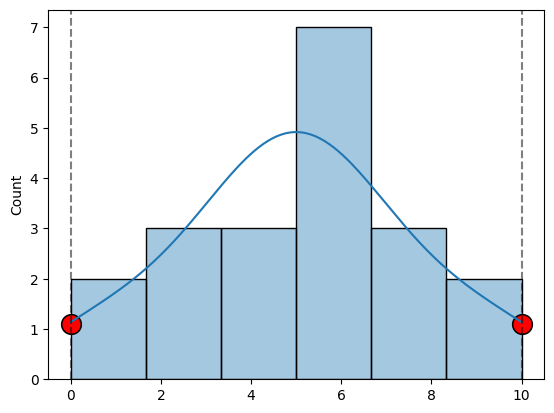

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# your data
data = [0, 1, 2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7, 8, 9, 10]

# example outliers (replace with yours)
outliers = [0, 10]

# create KDE function
kde = gaussian_kde(data)

# get y-values (density) for outliers
y_vals = kde(outliers)

# plot histogram + KDE
sns.histplot(data, kde=True, alpha=0.4)

# plot outliers exactly on KDE curve
sns.scatterplot(x=outliers, y=y_vals *32, color='red', s=200, edgecolor='black')

for x in outliers:
    plt.axvline(x, linestyle='--', color='black', alpha=0.5)





plt.show()